<a href="https://colab.research.google.com/github/lumizel/AI_26/blob/main/05_02_%EA%B5%90%EC%B0%A8%EA%B2%80%EC%A6%9D_%EA%B7%B8%EB%A6%AC%EB%93%9C%EC%84%9C%EC%B9%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 지금까지 배운 알고리즘은 훈련세트와 테스트세트를 나누어평가를 진행하는데
# 근데 결국 테스트세트로 평가를 하면 테스트세트에 맞는 모델이 만들어 지는 결론이 나온다
# 테스트 세트에 일반화 성능을 올바르게 예측하려면 가능한 한
# 테스트세트를 사용하지 말아야 한다.
# 모델을 만들고 나서 마지막에 딱 한번 사용하는 것이 좋다.

# 결정트리에서 배운 max_depth=3으로 테스트 해봤는데 이것이 최선일까?
# 결정트리에서 max_depth 매개변수를 사용한 하이퍼파라미터 튜닝 해보자.

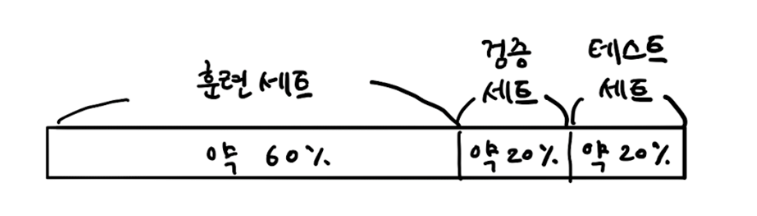

In [ ]:
# 검증세트
# 테스트 세트를 사용하지 않으려면 모델이 과대적합인지
# 과소적합인지 판단하기 어렵다.
# 테스트 세트를 사용하지 않고 측정하는 간단한 방법은
# 훈련세트를 또 나누는 것이다.
# 훈련세트 60%, 검증세트 20%, 테스트세트 20% -> 실무에서 많이 쓰는 기법

# 테스트하고 싶은 매개변수를 바꿔가면서 가장 좋은 모델이 나올 수 있음
# 이 매개변수를 사용해 훈련세트와 검증세트를 합쳐
# 전체 훈련 데이터에서 모델을 다시 훈련함
# 마지막 테스트에서 최종 점수를 평가함
# 훈련세트에서 모델을 훈련하고 검증세트로 모델을 평가함.
# 마지막 세트에서 테스트세트를 이용해 최종 점수를 평가함.

In [ ]:
import pandas as pd
import requests
import io
import urllib3

# 1. "보안 검증 안 해도 되니까 경고 띄우지 마!" 설정
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# 2. requests로 데이터를 강제로 가져오기 (verify=False가 핵심)
url = 'https://bit.ly/wine_csv_data'
response = requests.get(url, verify=False)

# 3. 판다스에게 주소 대신 '이미 가져온 데이터'를 읽으라고 시키기
# pd.read_csv('https://...') 대신 아래 방식을 써야 에러가 안 납니다!
wine = pd.read_csv(io.StringIO(response.text))

data = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

from sklearn.model_selection import train_test_split
# 훈련세트와 테스트 세트를 나눔
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42) # 20%
# 원본데이터 6497개 20% = train(5197) , test(1300)

print(train_input.shape, test_input.shape) # 처음엔 테스트용 20%를 분할

(5197, 3) (1300, 3)


In [ ]:
# 검증세트 20% 생성
sub_input, val_input, sub_target, val_target = train_test_split(train_input,train_target,test_size=0.2, random_state=42)

print(sub_input.shape, val_input.shape)
# 원래 5197개였던 훈련세트가 4157개로 줄고, 검증세트가 1040개가 됨
# 2중으로 또 다시 나눔

(4157, 3) (1040, 3)


In [ ]:
# sub_input, val_input, sub_target, val_target을 사용해 모델을 만들고 평가

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(sub_input, sub_target)

print(dt.score(sub_input, sub_target)) # 과대 적합
print(dt.score(val_input, val_target))
# 매개 변수를 바꿔서 더 좋은 모델을 찾아야 함

0.9971133028626413
0.864423076923077


In [ ]:
# 검증세트를 만드느냐고 훈련세트가 줄었음 (이럴 땐 많은 데이터를 훈련하면 좋은 결과가 나옴)
# 교차 검증 : 검증 세트를 떼어 내어 평가하는 과정을 여러번 반복함
# [훈련세트, 훈련세트, 검증세트]
# [훈련세트, 검증세트, 훈련세트]
# [검증세트, 훈련세트, 훈련세트] -> 패리티 방식(3-폴드 교차 검증)
# 5-폴드, 10-폴드도 있음
# 사이킷런에는 cross_validate()라는 교차 검증 함수를 사용

from sklearn.model_selection import cross_validate

# 평가할 모델 객체를 첫번째 매개변수로 전달함(직접 검증세트로 떼지않고, 훈련세트 전체를 전달함)
scores = cross_validate(dt,train_input,train_target,cv=5)
# cv 매개변수를 이용해 플드 수를 변경함 cv=5개로
print(scores)
# fit_time(훈련시간), score_time(검증시간), test_score(최종점수) 키를 가진 딕셔너리(k : v)를 반환함

{'fit_time': array([0.00581098, 0.00496078, 0.00531077, 0.00494361, 0.00482297]), 'score_time': array([0.00097132, 0.00107193, 0.00083804, 0.00073791, 0.00062013]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [ ]:
# {'fit_time : 훈련시간 ': array([0.01590347, 0.01357985, 0.0125258 , 0.01266432, 0.01209831]),
#  'score_time : 검증시간 ': array([0.0026319 , 0.00208259, 0.00182867, 0.00198817, 0.00206494]),
#  'test_score : 검증점수 ': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}

In [ ]:
import numpy as np
print(np.mean(scores['test_score'])) # test_score 이름이지만 검증폴드의 점수임
# 5개의 검증 점수를 평균을 내어 최종 점수를 얻는다. 85.53%

0.855300214703487


In [ ]:
# 주의 : cross_validate()는 훈련세트를 섞어서 폴드를 나누지 않음 -> 분할기 사용(splitter)
# 앞서 우리는 tarin_test_split() 함수로 전체 데이터를 섞은 후 훈련세트를 준비했음
# 만약 교차 검증을 할 때 훈련세트를 섞으려면 분할기(splitter)를 지정해야 한다.

# 사이킷런의 분할기는 교차검증에서 폴드를 어떻게 나눌지를 결정함
# cross_validate()는 기본적으로 회귀모델인 KFold 분할기를 사용함
# 분류 모델일 경우 타킷 클래스를 골고루 나누기 위해서 StratifiedKFold를 사용한다.
from sklearn.model_selection import StratifiedKFold # 스트래티파이드(계층화된)

# scores = cross_validate(dt, train_input, train_target, cv=StratifiedKFold())
splitter = StratifiedKFold()
scores = cross_validate(dt, train_input,train_target,cv=splitter)

print(scores)

{'fit_time': array([0.00454307, 0.00431299, 0.00590611, 0.00482368, 0.00440288]), 'score_time': array([0.00061536, 0.00056553, 0.0008378 , 0.00079727, 0.00051832]), 'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}


In [ ]:
# {'fit_time': array([0.02692175, 0.03336358, 0.02086091, 0.03042316, 0.02657533]),
#  'score_time': array([0.00191808, 0.00214911, 0.00205112, 0.00239015, 0.00949883]),
#   'test_score': array([0.86923077, 0.84615385, 0.87680462, 0.84889317, 0.83541867])}
print(np.mean(scores['test_score']))   # 85.53%

0.855300214703487


In [ ]:
splitter = StratifiedKFold(n_splits=10,shuffle=True,random_state=42) # 10폴드 교차 검증 수행
scores = cross_validate(dt,train_input,train_target,cv=splitter)
print(scores) # 10번의 교차검증이 진행
print(np.mean(scores['test_score'])) # 10번의 검증 평균 85.74%


# 'fit_time': array([0.00968313, 0.00927114, 0.01028776, 0.00924087, 0.00903869,
#                    0.00937033, 0.0128212 , 0.01320004, 0.0094955 , 0.0092895 ]),
# 'score_time': array([0.00123453, 0.00114727, 0.00116682, 0.001086  , 0.00115728,
#                      0.00110984, 0.00175667, 0.00167656, 0.00109053, 0.00124025]),
# 'test_score': array([0.83461538, 0.87884615, 0.85384615, 0.85384615, 0.84615385,
#                      0.87307692, 0.85961538, 0.85549133, 0.85163776, 0.86705202])}

{'fit_time': array([0.00598097, 0.00769186, 0.00758171, 0.00577807, 0.00566816,
       0.00567293, 0.00491142, 0.00573707, 0.00503087, 0.0048213 ]), 'score_time': array([0.00187755, 0.00108719, 0.00112176, 0.00071287, 0.00118613,
       0.00054336, 0.00045943, 0.0007534 , 0.00048518, 0.00044942]), 'test_score': array([0.83461538, 0.87884615, 0.85384615, 0.85384615, 0.84615385,
       0.87307692, 0.85961538, 0.85549133, 0.85163776, 0.86705202])}
0.8574181117533719


In [ ]:
# 결정트리의 매개변수 값을 바꿔가며 가장 좋은 성능이 나오는 모델을 찾아봐야 함
# 테스트 세트를 사용하지 않고 교차 검증을 통해서 좋은 모델을 골라야 함

# 하이퍼파라미터 튜닝
# 모델 파라미터 : 머신런닝 모델이 학습하는 파라미터
# 하이퍼파라미터 : 사용자가 지정해야만 하는 파라미터
# 하이퍼파라미터 튜닝 : 라이브러리가 제공하는 기본값을 그대로 사용해 모델을 훈련
# 그 다음 검증세트의 점수나 교차 검증을 통해서 매개변수를 조금씩 변경 1~2, 5~6개의 매개변수를 제공
# AutoML : 사람의 개입없이 하이퍼파라미터 튜닝을 자동으로 수행하는 기술

# Max_depth 를 최적으로 고정하고 min_sample_split을 바꿔가며 최적의 값을 찾는다면 값이 함께 변경됨
# -> 두개의 매개변수를 동시에 바꿔가며 최적의 값을 찾아야 함 -> 다중 for문을 사용해야 됨(복잡해 짐)
# 사이킷런에서 제공하는 그리드 서치(Grid Search)가 제공 GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV # 그리드서치 크로스 검증요
# min_impurity_decrease 매개변수의 최적값을 찾아보자
# min_sample_split : 샘플을 최소한 몇개 이상이어야 split(하위 노드로 분리) 할것인지
#   클수록 가지치기(과대적합 방지), 작을 수록 정확하기(과대적합)
parmas = {'min_impurity_decrease': [0.0001, 0.0002, 0.0003, 0.0004, 0.0005]} # 0.0001 ~ 증가 5번
# params = {'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001), # 9번
#           'max_depth': range(5, 20, 1),                              # 5~20까지 15번
#           'min_samples_split': range(2, 100, 10)   # 분할 할 수 있는 샘플수를 지정 2~100까지 10번
#           }

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), parmas, n_jobs= -1, cv=5)
# 결정 트리 클래스의 객체를 생성하자마자 바로 전달 함
# 일반 모델을 훈련하는 것 처럼 fit() 메서드를 호출 함
# 이 메서드를 호출 하면 서치 객체는 결정 트리 모델 min_impurity_decrease 값을 바꿔가면서 총 5번 수행
# GridSearchCV의 cv 매개변수 기본 값은 5임 5*5 = 25 번 수행
# n_jobs에서 병렬 실행에 사용될 CPU 코어수를 지정함 (-1로 사용시 모든 코어)

gs.fit(train_input, train_target) # 그리드서치를 이용한 훈련시작
# 교차 검증에서 최적의 하이퍼파라미터를 찾으면 전체 훈련 세트로 모델을 다시 만들어야 하지만
# 사이킷런의 그리드 서치는 검증 점수가 가장 높은 모델의 매개변수 조합으로
# 전체 훈련 세트에서 자동으로 다시 모델을 훈련 함

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'min_impurity_decrease': [0.0001, 0.0002, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold 

In [ ]:
# 이렇게 최적화되어 훈련된 모델은 GridSearchCV 클래스로 만들어진
# 객체의 best_estimator_ (에스티메이터) 속성에 저장되어 있다.
# 최적의 매개변수는 best_params_ 속성에 저장되어 있다.
print(f'그리드 서치를 통해 찾은 최적의 모델의 정확도 : {gs.score(train_input, train_target)*100:.2f}%')

그리드 서치를 통해 찾은 최적의 모델의 정확도 : 96.15%


In [ ]:
print(f'최적의 매개변수 : {gs.best_params_}')
# 각 매개변수에서 수행한 교차 검증의 평균 점수는 cv_results_ 속성의 'mean_test_score'키에 저장되어 있음
# 최적의 매개변수 : {'min_impurity_decrease': 0.0001}

최적의 매개변수 : {'min_impurity_decrease': 0.0001}


In [ ]:
# 다섯 번의 교차 검증으로 얻은 점수를 출력해보자
print(gs.cv_results_['mean_test_score']) # 첫 번째 값이 가장 큰것 같다!!!

[0.86819297 0.86453617 0.86492226 0.86780891 0.86761605]


In [ ]:
# 눈으로 보는 것 보다 넘파이를 이용해 argmax()함수를 사용하면 가장 큰 값의 인덱스를 추출할 수 있다
# 그 다음 이 인덱스를 사용해서 parmas 키에 저장된 매개변수를 출력
# 이 값이 최상의 검증 점수를 만듬 매개변수의 조합이 된다
best_index = np.argmax(gs.cv_results_['mean_test_score'])
print(gs.cv_results_['params'][best_index])

# 과정 요약
# 1. 탐색할 매개변수 지정
# 2. 훈련 세트에서 그리드 서치를 수행하여 최상의 평균 검증 점수가 나오는 매개변수 조합을 찾음
#    -> 그리드 서치에 저장
# 3. 그리드 서치는 최상의 매개변수에서 전체 훈련 세트를 사용해 최종 모델을 훈련
#    -> 그리드 서치에 저장

{'min_impurity_decrease': 0.0001}


In [ ]:
# 조금 더 복잡한 매개변수 조합 해보겠음
# 노드를 분할하기 위한 불순도 감소 최소량 지정 max_depth(트리의 깊이)
# min_samples_split 노드를 나누기 위한 최소 샘플 수
# 넘파이 arange() 함수는 첫번째 매개변수 값에서 시작해서
# 두번째 매개변수에 도달할 때까지 세번째 매개변수를 계속 더한 배열을 만듬

# 0.0001 ~ 0.001까지 0.0001을 더한 배열 (두번째 매개변수는 포함되지 않음) = 9번
# 파이썬 range() 함수는 정수만 사용가능 5~20까지 1씩 증가 = 15개
# 교차 검증 회수 9*15*10=1350개 * 5(5-폴드교차) = 6750개

parmas = {'min_impurity_decrease': np.arange(0.0001,0.001,0.0001), # 9번
          'max_depth' : range(5,20,1),                             # 5~20번까지 15번
          'min_samples_split' : range(2,100,10)}          # 분할 할 수 있는 샘플 수를 지정 2~100까지 10번

# criterion : 분할 품질을 측정하는 기능 (default : gini)
# splitter : 각 노드에서 분할을 선택하는 데 사용되는 전략 (default : best)
# max_depth : 트리의 최대 깊이 (값이 클수록 모델의 복잡도가 올라간다.)
# min_samples_split : 자식 노드를 분할하는데 필요한 최소 샘플 수 (default : 2)
# min_samples_leaf : 리프 노드에 있어야 할 최소 샘플 수 (default : 1)
# min_weight_fraction_leaf : min_sample_leaf와 같지만 가중치가 부여된 샘플 수에서의 비율
# max_features : 각 노드에서 분할에 사용할 특징의 최대 수
# random_state : 난수 seed 설정
# max_leaf_nodes : 리프 노드의 최대수
# min_impurity_decrease : 최소 불순도
# min_impurity_split : 나무 성장을 멈추기 위한 임계치
# class_weight : 클래스 가중치
# presort : 데이터 정렬 필요 여부

gs = GridSearchCV(DecisionTreeClassifier(random_state=42), parmas, n_jobs= -1)
gs.fit(train_input, train_target)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(5, 20), 'min_impurity_decrease': array([0.0001... 0.0009]), 'min_samples_split': range(2, 100, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [ ]:
print(gs.best_params_) # 최상의 매개변수 조합확인

{'max_depth': 14, 'min_impurity_decrease': np.float64(0.0004), 'min_samples_split': 12}


In [ ]:
print(np.max(gs.cv_results_['mean_test_score'])) # 최상의 교차 점수 확인
# 개선점 : 탐색 할 매개변수 간격을 0.0001 혹은 1로 설정 했는데 근거 부족 (좁히거나 넓힐 필요성?)

0.8683865773302731


In [ ]:
# 매개 변수의 값이 수치일 때 값의 범위나 간격을 미리 정하기 어려울 수 있음
# 너무 많은 매개 변수 조건이 있어 그리드 서치 수행시간이 오래 걸림

# 해결 : 랜덤 서치를 사용

# 랜덤서치 : 매개변수의 값의 목록을 전달하는 것이 아니라 매개변수를 샘플링할 수 있는 확률 분포도 객체를 전달
# 싸이파이 : 파이썬의 핵심 과학 라이브러리로 적분, 보간, 선형대수, 확률 등 포함한 수치 계산용 전용 라이브러리(코랩에 내장)

from scipy.stats import uniform, randint

# uniform, randint 클래스 모두 주어진 범위에서 골고루 값을 뽑늗다 (균등 분포에서 샘플링)
# randint()에서는 정수값을 추출, uniform() 실수 값을 추출

In [ ]:
# 랜덤서치 테스트
rgen = randint(0,10) # 10개 숫자를 샘플링(학생마다 다름)
rgen.rvs(10)
# 10개밖에 되지 않기 때문에 고르게 샘플링되는 것 같지 않지만 샘플링 숫자를 늘리면 쉽게 확인 할 수 있다.
# array([5, 8, 2, 6, 4, 9, 1, 2, 6, 4])

array([9, 0, 6, 1, 6, 2, 6, 1, 6, 8])

In [ ]:
np.unique(rgen.rvs(1000), return_counts=True)  # 1000개를 샘플링해서 각 숫자의 개수를 세어봄

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([100,  93, 100,  93,  96, 117, 104, 112,  94,  91]))

In [ ]:
ugen = uniform(0,1)
ugen.rvs(10)

array([0.83126376, 0.63160717, 0.27694003, 0.90188029, 0.0771561 ,
       0.75025412, 0.08640327, 0.36981115, 0.75998681, 0.73148826])

In [ ]:
# 탐색할 매개변수의 딕서너리를 만들어 봄
# min_samples_leaf을 탐색 대상에 추가 (랜덤값을 하이퍼파라이터값으로 적용)
params = {'min_impurity_decrease': uniform(0.0001, 0.001), # 0.00001 ~ 0.001의 실수값
          'max_depth': randint(20, 50),                   # 20~50 사이의 정수
          'min_samples_split': randint(2, 25),            # 2~25 사이의 정수
          'min_samples_leaf': randint(1, 25),             # 1~25 사이의 정수
          # 리프 노드가 되기 위한 최소 샘플 개수(지식 노드의 샘플 수가 이 값보다 작으면 분할 하지 않음)
          }

In [ ]:
# 어짜피 하이퍼파라미터의 매개값을 랜덤으로 하기로 했으니 검증하는 cv클래스도 랜덤용으로 사용
# 샘플링 횟수는 사이킷런의 랜덤 서치 클래스인 RandomizedSearchCV의 n_iter 매개변수에 지정
from sklearn.model_selection import RandomizedSearchCV

gs = RandomizedSearchCV(DecisionTreeClassifier(random_state=42), params, n_iter=100, n_jobs=-1,random_state=42)

# n_iter =100 총 100번을 샘플링하여 교차 검증 수행
gs.fit(train_input, train_target)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': <scipy.stats....001A4404AE350>, 'min_impurity_decrease': <scipy.stats....001A4404AC690>, 'min_samples_leaf': <scipy.stats....001A43F8C7E10>, 'min_samples_split': <scipy.stats....001A4404AD090>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User G

In [ ]:
print(gs.best_params_) # 결과 최적의 매개변수 조합을 찾음

{'max_depth': 39, 'min_impurity_decrease': np.float64(0.00034102546602601173), 'min_samples_leaf': 7, 'min_samples_split': 13}


In [ ]:
print(np.max(gs.cv_results_['mean_test_score']))  # 최고의 교차 검증 점수 확인
 # 86.95%의 검증 점수

0.8695428296438884


In [ ]:
dt = gs.best_estimator_
# 최종 모델 결정하고 테스트 세트의 성능을 확인
print(dt.score(test_input,test_target)) # 검증점수 86.95% , 테스트점수 86.00%

0.86


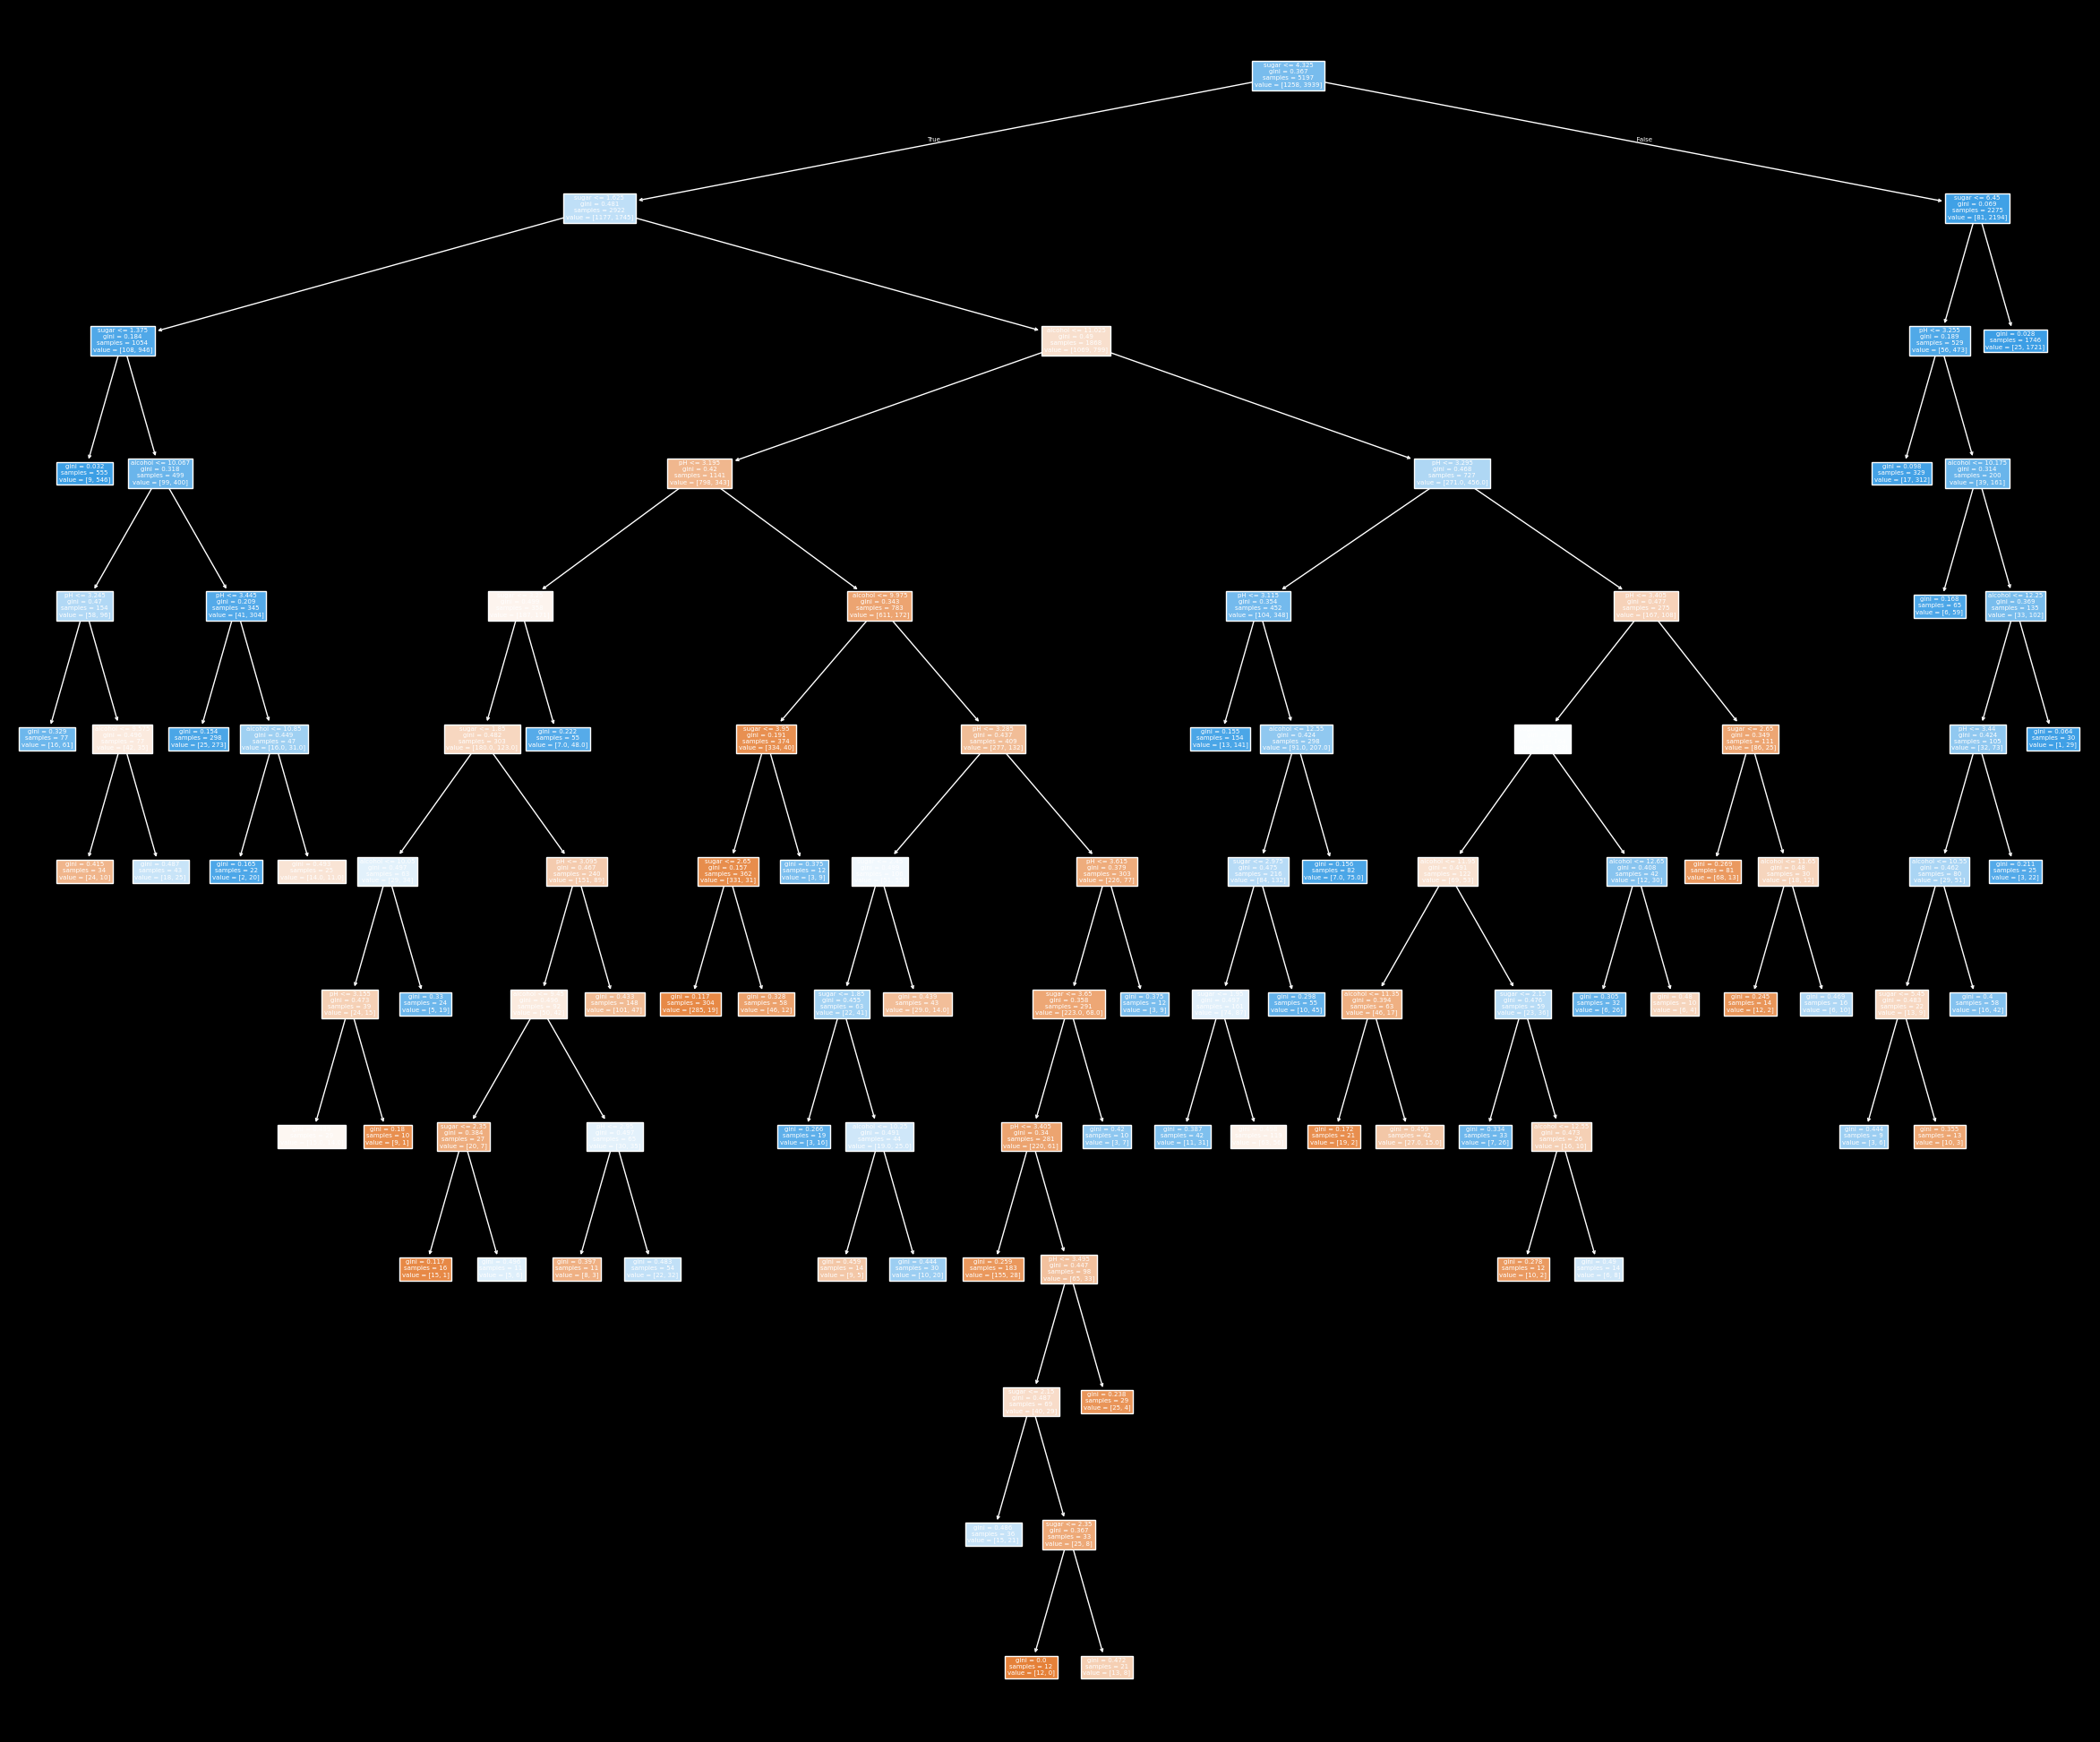

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(30,25))
plot_tree(dt,filled=True, feature_names=['alcohol', 'sugar', 'pH'])
plt.show()